<a href="https://colab.research.google.com/github/Giraffe-Shin/trading/blob/main/Basic/Basic_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
from google.colab import userdata

# 기존 설정 재사용
try:
    github_token = userdata.get('GITHUB_TOKEN')
except Exception:
    github_token = 'YOUR_TOKEN_HERE'

username = 'Giraffe-Shin'
repo = 'trading'
branch = 'main' # 이 부분은 contents API에서는 직접적으로 사용되지 않지만, 다른 작업 시 필요할 수 있습니다.
directory_path = 'data'

# GitHub API를 사용하여 디렉토리 내용 가져오기
api_url = f'https://api.github.com/repos/{username}/{repo}/contents/{directory_path}'

headers = {
    'Authorization': f'token {github_token}',
    'Accept': 'application/vnd.github.v3+json' # GitHub API 버전 3 사용 명시
}

try:
    response = requests.get(api_url, headers=headers)

    if response.status_code == 200:
        contents = response.json()
        file_names = [item['name'] for item in contents if item['type'] == 'file']
        print(f"'{directory_path}' 디렉토리의 파일 목록:")
        for file_name in file_names:
            print(f"- {file_name}")
    elif response.status_code == 401:
        print("인증 실패: 토큰이 유효하지 않거나 권한이 없습니다. GitHub 토큰을 확인해주세요.")
    elif response.status_code == 404:
        print(f"디렉토리 '{directory_path}'를 찾을 수 없습니다. 경로를 확인해주세요.")
    else:
        print(f"파일 목록을 가져오는 데 실패했습니다. 상태 코드: {response.status_code}, 메시지: {response.text}")
except Exception as e:
    print(f"오류 발생: {e}")


'data' 디렉토리의 파일 목록:
- germany_actual_generation.csv
- germany_cbet_trading.csv
- germany_cbpf_physical_flow.csv
- germany_energy_master.csv
- germany_forecast_day_ahead.csv
- germany_market_prices.csv
- germany_renewable_share_daily.csv


In [38]:
import pandas as pd
import requests
from io import StringIO
from google.colab import userdata

# --- 필수 설정 ---
try:
    # Colab 보안 비밀(Secrets)에서 토큰을 가져옵니다.
    github_token = userdata.get('GITHUB_TOKEN')
except Exception:
    github_token = 'YOUR_TOKEN_HERE'

username = 'Giraffe-Shin'
repo = 'trading'
branch = 'main'
file_path = 'data/germany_actual_generation.csv'

# API를 통한 프라이빗 파일 접근 URL
url = f'https://raw.githubusercontent.com/{username}/{repo}/{branch}/{file_path}'

headers = {'Authorization': f'token {github_token}'}

try:
    response = requests.get(url, headers=headers)
    if response.status_code == 200:
        df = pd.read_csv(StringIO(response.text))
        print("성공적으로 파일을 불러왔습니다!")
        display(df.head())
    elif response.status_code == 401:
        print("인증 실패: 토큰이 유효하지 않거나 권한이 없습니다.")
    elif response.status_code == 404:
        print("파일을 찾을 수 없습니다(404). 토큰 이름, 경로, 브랜치명을 다시 확인해주세요.")
    else:
        print(f"실패했습니다. 상태 코드: {response.status_code}")
except Exception as e:
    print(f"오류 발생: {e}")

성공적으로 파일을 불러왔습니다!


,timestamp,Hydro pumped storage consumption,Cross border electricity trading,Nuclear,Hydro Run-of-River,Biomass,Fossil brown coal / lignite,Fossil hard coal,Fossil oil,Fossil coal-derived gas,...,Hydro pumped storage,Others,Waste,Wind offshore,Wind onshore,Solar,Load,Residual load,Renewable share of load,Renewable share of generation
0,2022-12-31 23:00:00,-1975.8,-12645.2,2460.7,1627.7,4022.8,3845.6,1825.5,306.0,670.0,...,127.0,187.4,1050.3,2739.0,27260.9,0.0,38691.8,8691.8,93.7,75.5
1,2022-12-31 23:15:00,-2009.5,-12544.0,2458.5,1624.8,4012.0,3847.7,1828.6,306.8,648.2,...,180.1,187.3,1049.1,2975.6,27311.5,0.0,38374.2,8087.1,95.1,75.7
2,2022-12-31 23:30:00,-2244.0,-12526.2,2459.6,1624.8,4010.0,3860.2,1825.2,306.9,648.2,...,106.9,187.2,1055.2,3269.6,27699.4,0.0,38248.0,7279.0,97.2,76.0
3,2022-12-31 23:45:00,-2077.3,-12515.4,2457.9,1622.0,4004.0,3861.6,1819.7,306.0,639.1,...,87.0,187.3,1043.6,3259.5,27170.0,0.0,38070.2,7640.6,96.3,75.8
4,2023-01-01 00:00:00,-1204.1,-15410.1,2457.7,1622.3,3988.4,3869.8,1811.4,306.0,635.0,...,547.7,187.3,1047.1,3144.1,27853.6,0.0,37733.4,6735.7,98.5,76.3


In [43]:
# 데이터프레임의 컬럼 이름 리스트 출력
column_list = df.columns.tolist()
print(column_list)

['timestamp', 'Hydro pumped storage consumption', 'Cross border electricity trading', 'Nuclear', 'Hydro Run-of-River', 'Biomass', 'Fossil brown coal / lignite', 'Fossil hard coal', 'Fossil oil', 'Fossil coal-derived gas', 'Fossil gas', 'Geothermal', 'Hydro water reservoir', 'Hydro pumped storage', 'Others', 'Waste', 'Wind offshore', 'Wind onshore', 'Solar', 'Load', 'Residual load', 'Renewable share of load', 'Renewable share of generation']


In [68]:
df_time = df.copy()
# timestamp 컬럼을 datetime 형식으로 변환
df_time['timestamp'] = pd.to_datetime(df_time['timestamp'])

# timestamp를 인덱스로 설정
df_time.set_index('timestamp', inplace=True)

# 15분 값으로 변환
df_time = df_time * (15/60)



# 제외할 컬럼 리스트
cols_to_exclude = [
    "Load",
    "Residual load",
    "Renewable share of generation",
    "Renewable share of load",
    "Cross border electricity trading"
]

# 해당 컬럼들을 제외하고 데이터프레임 업데이트 -> prod_df 만들었음
prod_df = df_time.drop(columns=cols_to_exclude)

# 'timestamp'를 제외한 모든 수치형 열의 합계를 구하여 새로운 'Total' 열 생성
prod_df['Total'] = prod_df.sum(axis=1)

# 결과 확인
display(prod_df)

,Hydro pumped storage consumption,Nuclear,Hydro Run-of-River,Biomass,Fossil brown coal / lignite,Fossil hard coal,Fossil oil,Fossil coal-derived gas,Fossil gas,Geothermal,Hydro water reservoir,Hydro pumped storage,Others,Waste,Wind offshore,Wind onshore,Solar,Total
timestamp,,,,,,,,,,,,,,,,,,
2022-12-31 23:00:00,-493.950,615.175,406.925,1005.700,961.400,456.375,76.500,167.500,470.500,4.550,18.275,31.750,46.850,262.575,684.750,6815.225,0.00,11530.100
2022-12-31 23:15:00,-502.375,614.625,406.200,1003.000,961.925,457.150,76.700,162.050,470.225,4.625,16.475,45.025,46.825,262.275,743.900,6827.875,0.00,11596.500
2022-12-31 23:30:00,-561.000,614.900,406.200,1002.500,965.050,456.300,76.725,162.050,473.300,4.675,16.350,26.725,46.800,263.800,817.400,6924.850,0.00,11696.625
2022-12-31 23:45:00,-519.325,614.475,405.500,1001.000,965.400,454.925,76.500,159.775,471.475,4.650,20.900,21.750,46.825,260.900,814.875,6792.500,0.00,11592.125
2023-01-01 00:00:00,-301.025,614.425,405.575,997.100,967.450,452.850,76.500,158.750,424.100,4.650,14.325,136.925,46.825,261.775,786.025,6963.400,0.00,12009.650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-10 11:30:00,-1115.450,NaN,572.075,911.725,1208.200,485.175,94.025,96.225,854.400,3.400,6.350,1.525,33.675,275.425,877.600,2323.450,7783.80,14411.600
2026-06-10 11:45:00,-1039.975,NaN,570.775,913.325,1229.650,495.350,94.025,91.625,847.750,3.400,6.175,1.525,33.675,275.325,838.800,2393.775,7547.45,14302.650
2026-06-10 12:00:00,-920.300,NaN,576.275,913.925,1257.375,484.925,94.025,94.350,829.425,3.400,12.400,1.550,33.675,273.775,756.525,2505.150,7343.05,14259.525


,Hydro pumped storage consumption,Nuclear,Hydro Run-of-River,Biomass,Fossil brown coal / lignite,Fossil hard coal,Fossil oil,Fossil coal-derived gas,Fossil gas,Geothermal,Hydro water reservoir,Hydro pumped storage,Others,Waste,Wind offshore,Wind onshore,Solar,Total
timestamp,,,,,,,,,,,,,,,,,,
2022-12-31 23:00:00,-493.950,615.175,406.925,1005.700,961.400,456.375,76.500,167.500,470.500,4.550,18.275,31.750,46.850,262.575,684.750,6815.225,0.00,11530.100
2022-12-31 23:15:00,-502.375,614.625,406.200,1003.000,961.925,457.150,76.700,162.050,470.225,4.625,16.475,45.025,46.825,262.275,743.900,6827.875,0.00,11596.500
2022-12-31 23:30:00,-561.000,614.900,406.200,1002.500,965.050,456.300,76.725,162.050,473.300,4.675,16.350,26.725,46.800,263.800,817.400,6924.850,0.00,11696.625
2022-12-31 23:45:00,-519.325,614.475,405.500,1001.000,965.400,454.925,76.500,159.775,471.475,4.650,20.900,21.750,46.825,260.900,814.875,6792.500,0.00,11592.125
2023-01-01 00:00:00,-301.025,614.425,405.575,997.100,967.450,452.850,76.500,158.750,424.100,4.650,14.325,136.925,46.825,261.775,786.025,6963.400,0.00,12009.650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-10 11:30:00,-1115.450,NaN,572.075,911.725,1208.200,485.175,94.025,96.225,854.400,3.400,6.350,1.525,33.675,275.425,877.600,2323.450,7783.80,14411.600
2026-06-10 11:45:00,-1039.975,NaN,570.775,913.325,1229.650,495.350,94.025,91.625,847.750,3.400,6.175,1.525,33.675,275.325,838.800,2393.775,7547.45,14302.650
2026-06-10 12:00:00,-920.300,NaN,576.275,913.925,1257.375,484.925,94.025,94.350,829.425,3.400,12.400,1.550,33.675,273.775,756.525,2505.150,7343.05,14259.525


In [61]:

# 일간 발전량 합계 계산 (Resampling) - 이제 df_daily의 모든 컬럼은 MWh 단위의 일간 합계가 됩니다.
df_daily = prod_df.resample('D').sum()

# 결과 확인
display(df_daily.head())

# 전체 평균 하루 발전량 확인
avg_daily_mwh = df_daily['Total'].mean()
print(f"\n평균 일간 발전량: {avg_daily_mwh:,.0f} MWh")

,Hydro pumped storage consumption,Nuclear,Hydro Run-of-River,Biomass,Fossil brown coal / lignite,Fossil hard coal,Fossil oil,Fossil coal-derived gas,Fossil gas,Geothermal,Hydro water reservoir,Hydro pumped storage,Others,Waste,Wind offshore,Wind onshore,Solar,Total
timestamp,,,,,,,,,,,,,,,,,,
2022-12-31,-2076.650,2459.175,1624.825,4012.200,3853.775,1824.750,306.425,651.375,1885.500,18.500,72.000,125.250,187.300,1049.550,3060.925,27360.45,0.000,46415.35
2023-01-01,-44209.675,59039.125,38259.775,100238.775,98466.525,43960.575,7364.550,14480.925,41959.175,424.850,1364.925,18567.625,4501.050,24920.200,108884.375,525642.15,43195.025,1087059.95
2023-01-02,-34002.225,59030.875,38484.825,104139.800,264249.150,69078.475,7344.000,13927.350,63627.950,426.525,1442.375,26412.350,5313.975,25994.200,87043.100,549755.00,33206.525,1315474.25
2023-01-03,-29577.450,59055.300,40855.050,106210.925,309240.225,141288.100,7206.400,12754.500,91119.675,451.150,1911.175,45942.650,6531.025,24549.025,102618.825,319672.85,44839.925,1284669.35
2023-01-04,-63993.850,58392.250,40164.375,105372.975,120699.500,111949.000,7144.600,10745.200,61686.450,427.375,1521.700,24322.725,4641.200,18211.625,123858.275,918830.35,13131.300,1557105.05



평균 일간 발전량: 1,152,723 MWh


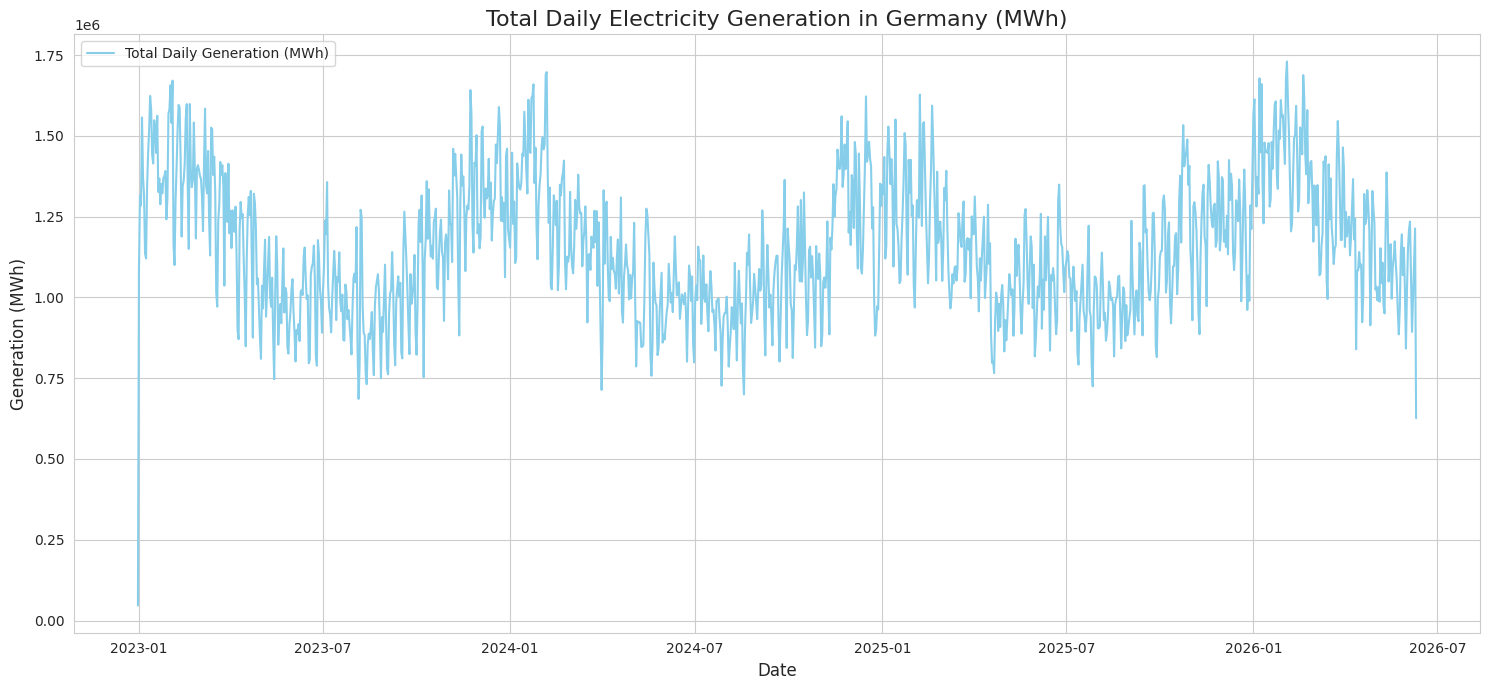


Insight 1: The plot above shows the trend of total daily electricity generation over time. We can observe seasonal patterns and overall changes in generation levels.


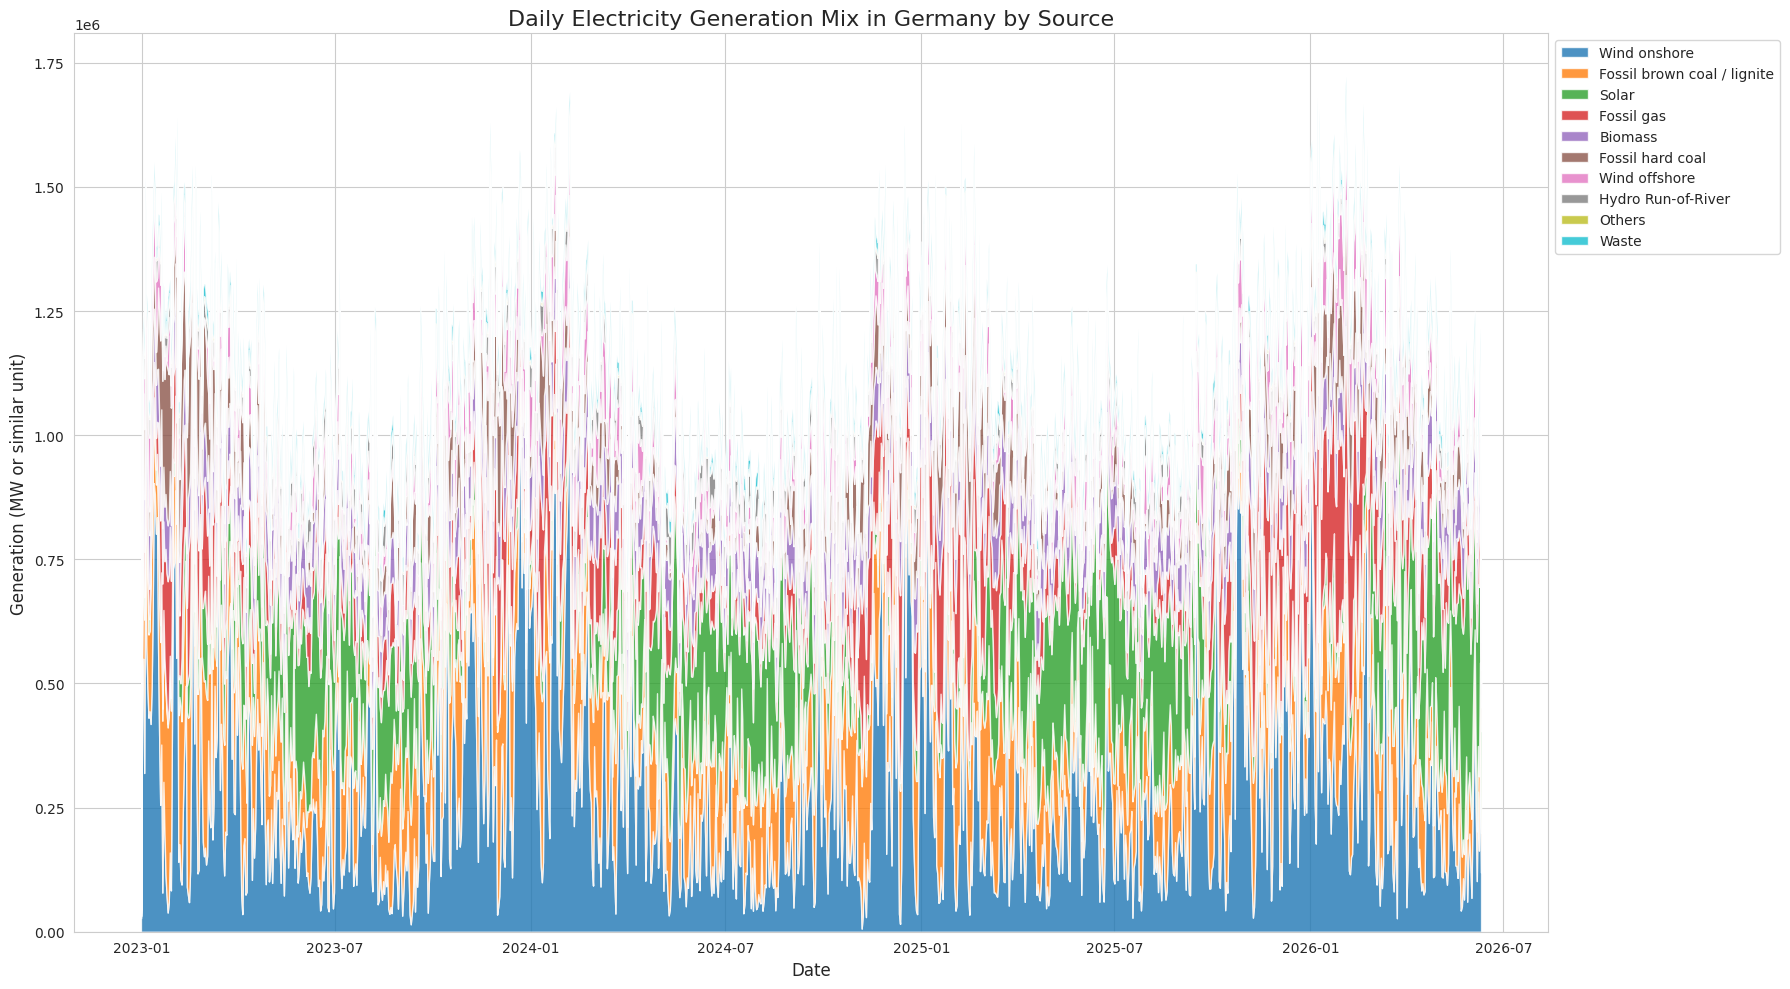


Insight 2: The stacked area chart illustrates the contribution of different energy sources to the total daily generation. This helps in understanding the energy mix, the dominance of certain sources (e.g., Fossil fuels, Wind, Solar), and how the reliance on these sources changes over time, potentially reflecting policy changes or seasonal availability (e.g., higher wind/solar in certain periods).
Insight 3: By observing the 'Fossil brown coal / lignite' and 'Fossil hard coal' trends, we can gauge the reliance on fossil fuels. Similarly, 'Wind offshore', 'Wind onshore', and 'Solar' show the growth and variability of renewable energy sources. Changes in 'Nuclear' generation might indicate plant shutdowns or operational changes.


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# 1. Total Daily Electricity Generation (MWh)
plt.figure(figsize=(15, 7))
plt.plot(df_daily['Total'].index, df_daily['Total'].values, label='Total Daily Generation (MWh)', color='skyblue')
plt.title('Total Daily Electricity Generation in Germany (MWh)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Generation (MWh)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nInsight 1: The plot above shows the trend of total daily electricity generation over time. We can observe seasonal patterns and overall changes in generation levels.")

# 2. Daily Generation Mix (Stacked Area Plot)
# Exclude aggregate columns like 'Total', 'total_MWh', 'Total_Calc' from the mix plot
cols_to_exclude_from_mix = []
if 'Total' in df_daily.columns:
    cols_to_exclude_from_mix.append('Total')
if 'total_MWh' in df_daily.columns:
    cols_to_exclude_from_mix.append('total_MWh')


if cols_to_exclude_from_mix:
    df_daily_plot = df_daily.drop(columns=cols_to_exclude_from_mix)
else:
    df_daily_plot = df_daily.copy()

# Select top N sources for clarity, or plot all if manageable
# For this example, let's take some key sources and 'Others'
# Sorting by mean generation to get prominent sources
sources_mean = df_daily_plot.mean().sort_values(ascending=False)

# Let's consider the top 8 sources plus 'Others' and 'Waste' if not in top 8
top_sources = sources_mean.head(8).index.tolist()

# Ensure 'Others' and 'Waste' are included if they are present in the dataframe
if 'Others' in df_daily_plot.columns and 'Others' not in top_sources:
    top_sources.append('Others')
if 'Waste' in df_daily_plot.columns and 'Waste' not in top_sources:
    top_sources.append('Waste')

# Filter df_daily_plot to include only the selected sources, ensuring they actually exist
existing_top_sources = [col for col in top_sources if col in df_daily_plot.columns]
df_daily_mix = df_daily_plot[existing_top_sources]

plt.figure(figsize=(18, 10))
# Convert to MWh for better comparison if needed, or keep in original units
# Assuming original units are already comparable or MWh transformation is done globally
plt.stackplot(df_daily_mix.index, df_daily_mix.values.T, labels=df_daily_mix.columns,
              alpha=0.8)
plt.title('Daily Electricity Generation Mix in Germany by Source', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Generation (MW or similar unit)', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nInsight 2: The stacked area chart illustrates the contribution of different energy sources to the total daily generation. This helps in understanding the energy mix, the dominance of certain sources (e.g., Fossil fuels, Wind, Solar), and how the reliance on these sources changes over time, potentially reflecting policy changes or seasonal availability (e.g., higher wind/solar in certain periods).")

print("Insight 3: By observing the 'Fossil brown coal / lignite' and 'Fossil hard coal' trends, we can gauge the reliance on fossil fuels. Similarly, 'Wind offshore', 'Wind onshore', and 'Solar' show the growth and variability of renewable energy sources. Changes in 'Nuclear' generation might indicate plant shutdowns or operational changes.")

In [71]:
import pandas as pd

# 1. 태양광(Solar), 풍력(Wind Onshore/Offshore) 비중 계산

# 비중 계산
df_daily['Solar_Share'] = df_daily['Solar'] / df_daily['Total']
df_daily['Wind_Onshore_Share'] = df_daily['Wind onshore'] / df_daily['Total']
df_daily['Wind_Offshore_Share'] = df_daily['Wind offshore'] / df_daily['Total']

# 2. 신재생 에너지 전체 비율 계산
renewable_cols = [
    'Hydro Run-of-River', 'Biomass', 'Geothermal',
    'Hydro water reservoir', 'Wind offshore', 'Wind onshore', 'Solar'
]

available_renewables = [col for col in renewable_cols if col in df_daily.columns]
df_daily['Renewable_Total_Share'] = df_daily[available_renewables].sum(axis=1) / df_daily['Total']


# 결과 확인
display_cols = ['Solar_Share', 'Wind_Onshore_Share', 'Wind_Offshore_Share', 'Renewable_Total_Share', 'Renewable_Share_of_Generation']
display(df_daily[display_cols].head())

print("\n[통계 요약]")
display(df_daily[display_cols].describe())

,Solar_Share,Wind_Onshore_Share,Wind_Offshore_Share,Renewable_Total_Share,Renewable_Share_of_Generation
timestamp,,,,,
2022-12-31,0.000000,0.589470,0.065946,0.778813,18.937500
2023-01-01,0.039736,0.483545,0.100164,0.752497,18.591146
2023-01-02,0.025243,0.417914,0.066169,0.619167,15.692708
2023-01-03,0.034904,0.248837,0.079880,0.479937,12.342969
2023-01-04,0.008433,0.590089,0.079544,0.772784,18.937240



[통계 요약]


,Solar_Share,Wind_Onshore_Share,Wind_Offshore_Share,Renewable_Total_Share,Renewable_Share_of_Generation
count,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000
mean,0.164812,0.248814,0.059445,0.609767,14.968923
std,0.118318,0.143944,0.030755,0.149473,3.531566
min,0.000000,0.006160,0.000161,0.196660,5.188021
25%,0.052493,0.129782,0.034288,0.515786,12.729883
50%,0.150179,0.225844,0.059054,0.624046,15.236458
75%,0.256662,0.343699,0.082414,0.728577,17.735091
max,0.496249,0.656520,0.142660,0.906694,22.316146


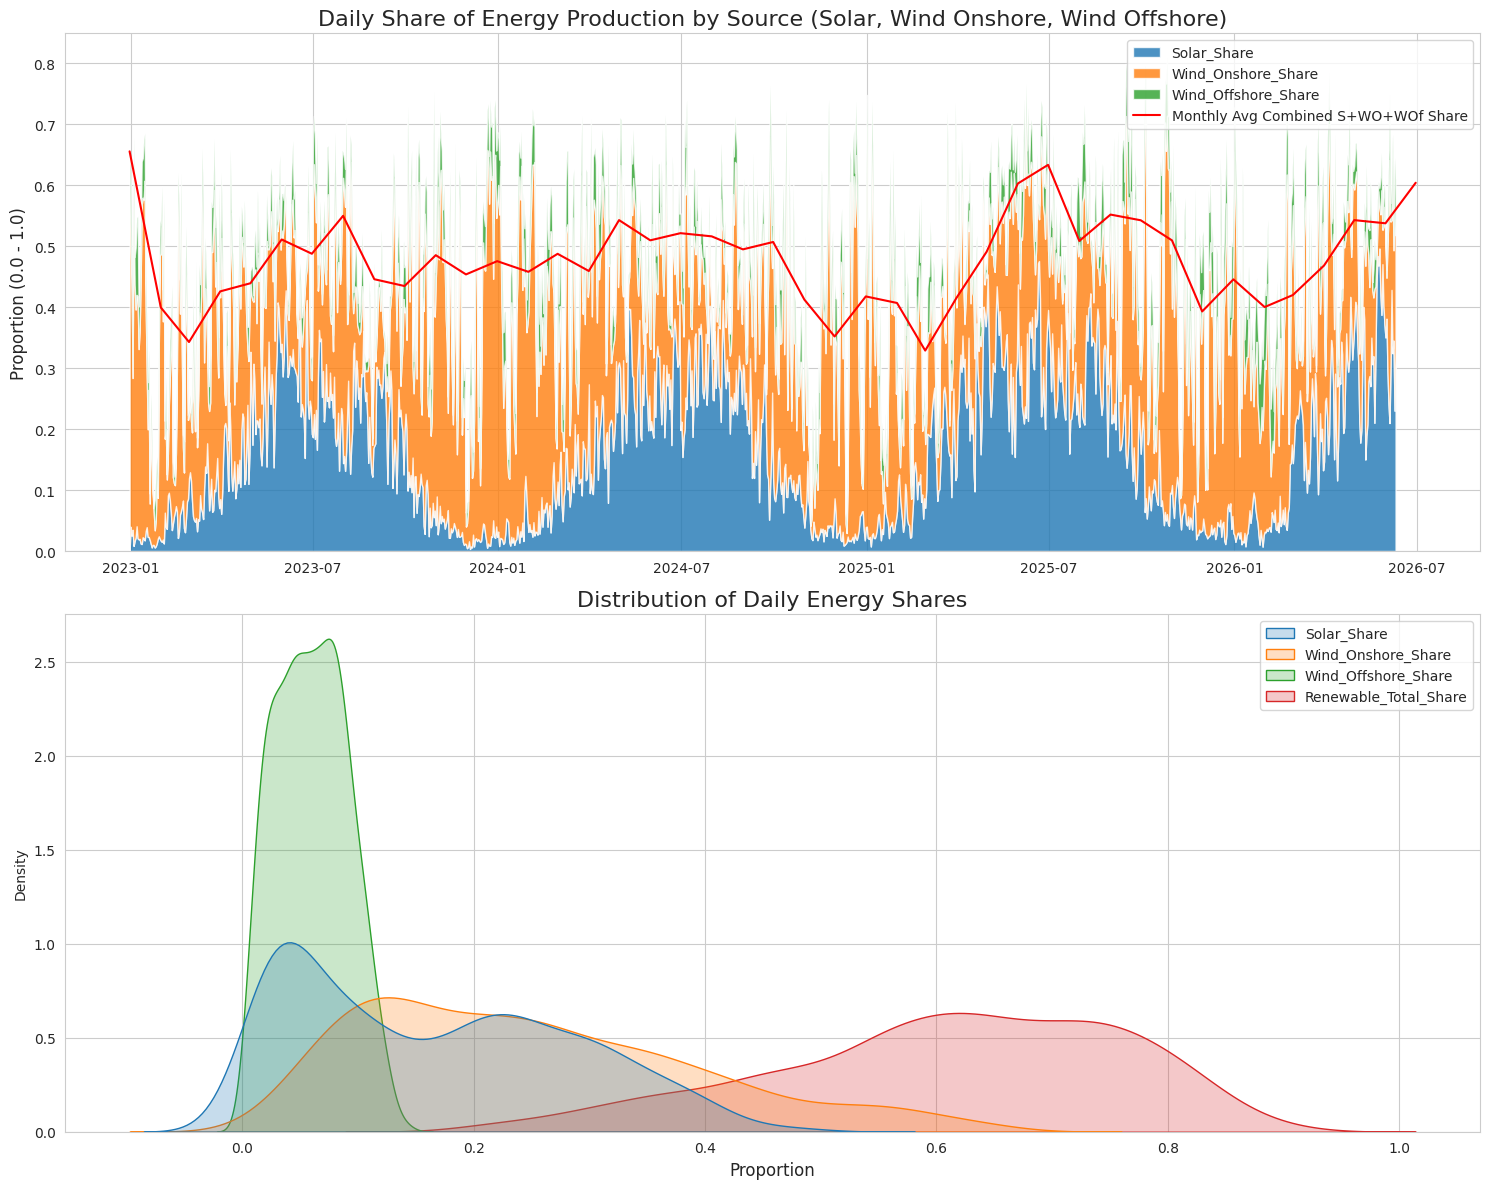

### [Key Insights from Energy Share Analysis] ###
1. 평균 신재생 에너지 비중: 전체 발전량 중 신재생 에너지가 차지하는 평균 비중은 약 61.0%로, 에너지 전환이 상당히 진행되었음을 보여줍니다.
2. 풍력 vs 태양광: 풍력(Onshore+Offshore)의 평균 비중(30.8%)이 태양광(16.5%)보다 높게 나타나며, 독일 에너지 생산의 핵심적인 역할을 하고 있습니다.
3. 변동성 리스크: 신재생 에너지 비중의 표준편차가 0.15로 나타나며, 기상 조건에 따라 하루 발전 비중이 급격히 변동하는 '간헐성' 문제가 시각적으로 확인됩니다.
4. 최대 공급 능력: 특정 일자에는 신재생 에너지 비중이 최대 90.7%까지 상승하며, 화석 연료 없이도 국가 전력 수요의 상당 부분을 충당할 수 있는 잠재력을 보여줍니다.


In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Ensure share columns are calculated before plotting ---
# 1. 태양광(Solar), 풍력(Wind Onshore/Offshore) 비중 계산


# 비중 계산
df_daily['Solar_Share'] = df_daily['Solar'] / df_daily['Total']
df_daily['Wind_Onshore_Share'] = df_daily['Wind onshore'] / df_daily['Total']
df_daily['Wind_Offshore_Share'] = df_daily['Wind offshore'] / df_daily['Total']

# 2. 신재생 에너지 전체 비율 계산
renewable_cols = [
    'Hydro Run-of-River', 'Biomass', 'Geothermal',
    'Hydro water reservoir', 'Wind offshore', 'Wind onshore', 'Solar'
]
available_renewables = [col for col in renewable_cols if col in df_daily.columns]
df_daily['Renewable_Total_Share'] = df_daily[available_renewables].sum(axis=1) / df_daily['Total']
# --- End of share columns calculation ---


# Set visualization style
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# 1. Trend of Energy Shares over Time (Stacked Area Plot for individual shares)
share_cols = ['Solar_Share', 'Wind_Onshore_Share', 'Wind_Offshore_Share']
plt.sca(axes[0]) # Set current axes to the first subplot
plt.stackplot(df_daily.index, df_daily[share_cols].values.T, labels=share_cols, alpha=0.8)

# Calculate and add a line plot for the monthly average of the sum of the three shares
df_daily['Combined_SWO_Share'] = df_daily['Solar_Share'] + df_daily['Wind_Onshore_Share'] + df_daily['Wind_Offshore_Share']
df_monthly_avg_combined = df_daily['Combined_SWO_Share'].resample('ME').mean()
axes[0].plot(df_monthly_avg_combined.index, df_monthly_avg_combined, color='red', linestyle='-', label='Monthly Avg Combined S+WO+WOf Share')

axes[0].set_title('Daily Share of Energy Production by Source (Solar, Wind Onshore, Wind Offshore)', fontsize=16)
axes[0].set_ylabel('Proportion (0.0 - 1.0)', fontsize=12)
axes[0].legend(loc='upper right')
axes[0].grid(True)

# 2. Distribution of Renewable Shares (including Wind_Offshore_Share) - remains unchanged
sns.kdeplot(data=df_daily[['Solar_Share', 'Wind_Onshore_Share', 'Wind_Offshore_Share', 'Renewable_Total_Share']], fill=True, ax=axes[1])
axes[1].set_title('Distribution of Daily Energy Shares', fontsize=16)
axes[1].set_xlabel('Proportion', fontsize=12)

plt.tight_layout()
plt.show()

# --- Insight Extraction ---
print("### [Key Insights from Energy Share Analysis] ###")

# 1. Renewable Dominance
avg_renewable = df_daily['Renewable_Total_Share'].mean() * 100
print(f"1. 평균 신재생 에너지 비중: 전체 발전량 중 신재생 에너지가 차지하는 평균 비중은 약 {avg_renewable:.1f}%로, 에너지 전환이 상당히 진행되었음을 보여줍니다.")

# 2. Wind vs Solar
wind_total_avg = (df_daily['Wind_Onshore_Share'].mean() + df_daily['Wind_Offshore_Share'].mean()) * 100
solar_avg = df_daily['Solar_Share'].mean() * 100
print(f"2. 풍력 vs 태양광: 풍력(Onshore+Offshore)의 평균 비중({wind_total_avg:.1f}%)이 태양광({solar_avg:.1f}%)보다 높게 나타나며, 독일 에너지 생산의 핵심적인 역할을 하고 있습니다.")

# 3. Variability & Volatility
renewable_std = df_daily['Renewable_Total_Share'].std()
print(f"3. 변동성 리스크: 신재생 에너지 비중의 표준편차가 {renewable_std:.2f}로 나타나며, 기상 조건에 따라 하루 발전 비중이 급격히 변동하는 '간헐성' 문제가 시각적으로 확인됩니다.")

# 4. Seasonal/Daily Peaks
max_renewable = df_daily['Renewable_Total_Share'].max() * 100
print(f"4. 최대 공급 능력: 특정 일자에는 신재생 에너지 비중이 최대 {max_renewable:.1f}%까지 상승하며, 화석 연료 없이도 국가 전력 수요의 상당 부분을 충당할 수 있는 잠재력을 보여줍니다.")